<div style="
    padding: 32px 36px;
    border-radius: 16px;
    background: linear-gradient(135deg, #102A43 0%, #243B53 100%);
    color: #F7F4EC;
    margin-bottom: 24px;
">
    <div style="font-size: 13px; letter-spacing: 0.16em; text-transform: uppercase; color: #D4A44C; font-weight: 700;">
        ConflictLens · Article reproduction notebook
    </div>
    <h1 style="margin: 10px 0 8px 0; font-size: 38px; font-weight: 700; color: #FFFFFF;">
        The line has risen again. But not everywhere.
    </h1>
    <p style="margin: 0; max-width: 860px; font-size: 17px; line-height: 1.55; color: #D9E2EC;">
        Reproduce the short article’s annual series, recent country-year concentration, violence-type composition and publication-ready outputs.
    </p>
    <div style="margin-top: 24px; padding-top: 16px; border-top: 1px solid rgba(255,255,255,0.20); font-size: 13px; color: #BCCCDC;">
        UCDP Organized Violence · 1989–2025 · descriptive, non-causal and reproducible
    </div>
</div>

## 1. Article purpose and analytical questions

This is a focused reproduction notebook for a short article. It does not rebuild the country-year panel and does not attempt a causal or geopolitical explanation.

It answers five questions:

1. How exceptional is the 2021–2025 sequence within the 1989–2025 record and across overlapping five-year windows?
2. How much of each recent annual total is carried by the two largest country-year contributors?
3. Did most comparable analytical units rise between 2024 and 2025?
4. Did the recorded composition of organized violence change between 2024 and 2025?
5. How sensitive is that compositional reading to UCDP's low, best and high estimates?

The editorial function is deliberately narrow: **observe, qualify, redirect**.


## Navigation

1. [Inputs, scope and guardrails](#inputs-scope)
2. [Data loading and validation](#data-loading)
3. [Full annual series](#annual-series)
4. [Recent top-two concentration](#recent-concentration)
5. [Violence-type composition](#composition)
6. [Article-ready outputs](#outputs)
7. [Assertions and validation summary](#validation)
8. [Reproduction notes](#reproduction)

<a id="inputs-scope"></a>

## 2. Inputs, scope and methodological guardrails

**Question**  
Which inputs and conventions allow the article arithmetic to be reproduced without changing the validated panel logic?

**Method**  
Use the analysis-ready country-year panel for the validated total-death series, top-contributor calculations and diffusion diagnostic. Use the staging panel for the three decomposed Organized Violence best-estimate fields that are not retained in the analysis-ready export. Use the official UCDP Organized Violence v26.1 source archive only for low/high sensitivity fields that the validated panels do not retain.

**Analytical universe**

- Grain: `analysis_unit_id + year`.
- Full period: 1989–2025.
- Composition period: 2010–2025.
- Universe filter: `analysis_conflict_universe == True` and `unit_exists_in_year == True`.
- Annual total metric: curated `ucdp_ov_total_deaths_best_zf` from the analysis-ready panel.
- Components: state-based, non-state and one-sided best estimates from staging, with the panel’s existing guarded zero-fill eligibility applied only where `ucdp_ov_can_zero_fill == True`.
- Sensitivity fields: official UCDP low and high estimates, aggregated globally from the supplied v26.1 source archive. These are estimate variants, not formal confidence intervals.

> **A country-year contribution records where a value enters the panel arithmetic. It is not a perpetrator attribution, victim identification, or legal or historical classification.**

**Limit**  
The notebook describes the distribution and composition of recorded deaths. It does not establish why conflicts occurred, why the global total changed, or how responsibility should be assigned.

In [1]:
from __future__ import annotations

import importlib.metadata as importlib_metadata
import importlib.util
import json
import math
import platform
import subprocess
import sys
import warnings
import zipfile
from datetime import datetime, timezone
from pathlib import Path

import numpy as np
import pandas as pd
from IPython.display import HTML, Markdown, display

REQUIRED_MODULES = {
    "pandas": "pandas",
    "numpy": "numpy",
    "matplotlib": "matplotlib",
    "pyarrow": "pyarrow",
    "PIL": "pillow",
}
missing_modules = [name for name in REQUIRED_MODULES if importlib.util.find_spec(name) is None]
if missing_modules:
    raise ImportError("Missing required package(s): " + ", ".join(missing_modules))

import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
from matplotlib import font_manager
from matplotlib.patches import Rectangle
from matplotlib.ticker import FuncFormatter
from PIL import Image

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 180)
pd.set_option("display.max_colwidth", 140)

COLORS = {
    "ink": "#102A43",
    "navy_2": "#243B53",
    "copper": "#D4A44C",
    "muted": "#66788A",
    "paper_2": "#EDE9DF",
    "border": "#D8D5CC",
    "white": "#FFFFFF",
    "paper": "#F7F4EC",
    "info_ink": "#1C4F8A",
    "ok": "#1F8A5B",
    "caution_ink": "#8A6D1F",
    "limit_ink": "#9C3B3B",
}
CATEGORICAL = ["#102A43", "#2F6B8A", "#3E7A78", "#7A6680", "#7B6E4B", "#66788A"]
FIGURE_PROFILES = {
    "inline": {"figsize": (8.0, 5.0), "dpi": 200, "pixels": (1600, 1000)},
    "wide": {"figsize": (12.0, 7.2), "dpi": 200, "pixels": (2400, 1440)},
    "full": {"figsize": (14.0, 8.0), "dpi": 200, "pixels": (2800, 1600)},
}
SANS = ["IBM Plex Sans", "DejaVu Sans", "Arial", "sans-serif"]
MONO = ["IBM Plex Mono", "DejaVu Sans Mono", "monospace"]
installed_fonts = {font.name for font in font_manager.fontManager.ttflist}
SANS_USED = "IBM Plex Sans" if "IBM Plex Sans" in installed_fonts else "DejaVu Sans"
MONO_USED = "IBM Plex Mono" if "IBM Plex Mono" in installed_fonts else "DejaVu Sans Mono"
IBM_PLEX_AVAILABLE = SANS_USED == "IBM Plex Sans" and MONO_USED == "IBM Plex Mono"

plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": SANS,
    "font.monospace": MONO,
    "figure.facecolor": COLORS["white"],
    "axes.facecolor": COLORS["white"],
    "savefig.facecolor": COLORS["white"],
    "savefig.transparent": False,
    "text.color": COLORS["navy_2"],
    "axes.labelcolor": COLORS["navy_2"],
    "axes.titlecolor": COLORS["ink"],
    "xtick.color": COLORS["muted"],
    "ytick.color": COLORS["muted"],
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.spines.left": False,
    "axes.edgecolor": COLORS["border"],
    "axes.linewidth": 0.8,
    "axes.grid": False,
    "axes.axisbelow": True,
    "grid.color": COLORS["paper_2"],
    "grid.linewidth": 0.8,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "axes.labelsize": 12,
    "legend.fontsize": 11,
    "figure.dpi": 120,
    "savefig.dpi": 200,
})

START_YEAR = 1989
END_YEAR = 2025
RECENT_START = 2021
RECENT_PEAK_YEAR = 2022
COMPARISON_YEAR = 2024
COMPOSITION_START = 2010
ARTICLE_SLUG = "the-line-is-rising-but-not-everywhere"
NOTEBOOK_NAME = "03_the_line_is_rising_but_not_everywhere.ipynb"


def locate_project_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / "pyproject.toml").exists() and (candidate / "notebooks").exists():
            return candidate
    raise FileNotFoundError("Could not locate the ConflictLens project root.")


PROJECT_ROOT = locate_project_root(Path.cwd())
FIGURE_DIR = PROJECT_ROOT / "figures" / ARTICLE_SLUG
VALIDATION_DIR = FIGURE_DIR / "validation"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)
VALIDATION_DIR.mkdir(parents=True, exist_ok=True)


def detect_source_commit(project_root: Path) -> tuple[str | None, str]:
    if not (project_root / ".git").exists():
        return None, "Unavailable: supplied workspace archive contains no .git directory."
    try:
        commit = subprocess.check_output(
            ["git", "-C", str(project_root), "rev-parse", "HEAD"],
            text=True,
            stderr=subprocess.STDOUT,
        ).strip()
        return commit, "Detected from Git metadata."
    except Exception as exc:
        return None, f"Unavailable: git rev-parse failed ({exc!r})."


SOURCE_COMMIT, SOURCE_COMMIT_STATUS = detect_source_commit(PROJECT_ROOT)


def fmt_int(value: float | int) -> str:
    return f"{int(round(float(value))):,}"


def fmt_pct(value: float, decimals: int = 1) -> str:
    return f"{float(value) * 100:.{decimals}f}%"


def fmt_delta_k(value: float) -> str:
    rounded = int(round(abs(float(value)) / 1000))
    sign = "+" if value >= 0 else "−"
    return f"{sign}{rounded}k"


def display_note(title: str, text: str, kind: str = "info") -> None:
    colors = {
        "info": (COLORS["info_ink"], "#DCEEFF", COLORS["ink"]),
        "success": (COLORS["ok"], "#DFF3E4", COLORS["ink"]),
        "warning": (COLORS["caution_ink"], "#FFF3CD", COLORS["ink"]),
        "error": (COLORS["limit_ink"], "#FDE2E2", COLORS["ink"]),
    }
    border, background, foreground = colors[kind]
    display(HTML(
        f"<div style='box-sizing:border-box;width:100%;max-width:100%;overflow-x:hidden;overflow-wrap:anywhere;"
        f"padding:15px 18px;border-left:5px solid {border};border-radius:6px;background:{background};"
        f"color:{foreground};line-height:1.55;margin:14px 0;'><strong>{title}</strong><br>{text}</div>"
    ))


def style_axis(ax: plt.Axes, *, grid: str | None = "y") -> None:
    ax.spines["bottom"].set_color(COLORS["border"])
    ax.spines["bottom"].set_linewidth(0.9)
    if grid:
        ax.grid(axis=grid, color=COLORS["paper_2"], linewidth=0.8)
    ax.tick_params(axis="both", length=0, pad=7)
    for label in ax.get_xticklabels():
        label.set_fontfamily(MONO_USED)
    for label in ax.get_yticklabels():
        label.set_fontfamily(MONO_USED)


def add_exact_canvas_anchor(fig: plt.Figure, profile: str = "wide", pad_inches: float = 0.16) -> None:
    """Make tight-bbox + padding resolve to the canonical profile dimensions.

    The transparent artist defines a tight bounding box inset by the exact export padding.
    Matplotlib then adds that padding back, yielding the requested canvas without a
    post-export crop or resize.
    """
    width_in, height_in = FIGURE_PROFILES[profile]["figsize"]
    anchor = Rectangle(
        (pad_inches / width_in, pad_inches / height_in),
        1 - 2 * pad_inches / width_in,
        1 - 2 * pad_inches / height_in,
        transform=fig.transFigure,
        facecolor="none",
        edgecolor="none",
        linewidth=0,
        clip_on=False,
    )
    fig.add_artist(anchor)


def mobile_preview(path: Path, width: int = 360) -> Image.Image:
    image = Image.open(path).convert("RGB")
    height = round(image.height * width / image.width)
    return image.resize((width, height), Image.Resampling.LANCZOS)


def export_publication_figure(
    fig: plt.Figure,
    filename: str,
    data: pd.DataFrame,
    *,
    figure_id: str,
    title: str,
    caption: str,
    alt_text: str,
    measure: str,
    universe: str,
    period: str,
    filters: list[str],
    categorical_mapping: dict[str, dict[str, str]],
    notes: str,
    profile: str = "wide",
) -> dict[str, Path]:
    stem = Path(filename).stem
    png_path = FIGURE_DIR / f"{stem}.png"
    svg_path = FIGURE_DIR / f"{stem}.svg"
    csv_path = FIGURE_DIR / f"{stem}_data.csv"
    metadata_path = FIGURE_DIR / f"{stem}_metadata.json"
    preview_path = VALIDATION_DIR / f"{stem}_360px.png"

    data.to_csv(csv_path, index=False)
    pad_inches = 0.16
    add_exact_canvas_anchor(fig, profile=profile, pad_inches=pad_inches)
    common = {
        "bbox_inches": "tight",
        "pad_inches": pad_inches,
        "facecolor": COLORS["white"],
        "transparent": False,
    }
    dpi = FIGURE_PROFILES[profile]["dpi"]
    fig.savefig(png_path, dpi=dpi, **common)
    fig.savefig(svg_path, **common)

    with Image.open(png_path) as image:
        width_px, height_px = image.size
        rgba = image.convert("RGBA")
        alpha_extrema = rgba.getchannel("A").getextrema()
        corner_pixels = [
            rgba.getpixel((0, 0)),
            rgba.getpixel((width_px - 1, 0)),
            rgba.getpixel((0, height_px - 1)),
            rgba.getpixel((width_px - 1, height_px - 1)),
        ]
    expected_pixels = FIGURE_PROFILES[profile]["pixels"]
    assert (width_px, height_px) == expected_pixels, ((width_px, height_px), expected_pixels)
    assert alpha_extrema == (255, 255), alpha_extrema
    assert all(pixel == (255, 255, 255, 255) for pixel in corner_pixels), corner_pixels

    preview = mobile_preview(png_path, width=360)
    preview.save(preview_path)
    assert preview.width == 360 and preview.height > 0

    metadata = {
        "figure_id": figure_id,
        "title": title,
        "article_slug": ARTICLE_SLUG,
        "caption": caption,
        "alt_text": alt_text,
        "source": "UCDP Organized Violence v26.1; ConflictLens calculations.",
        "measure": measure,
        "universe": universe,
        "period": period,
        "filters": filters,
        "profile": profile,
        "notebook": f"notebooks/articles/{NOTEBOOK_NAME}",
        "source_commit": SOURCE_COMMIT,
        "source_commit_status": SOURCE_COMMIT_STATUS,
        "categorical_mapping": categorical_mapping,
        "width_px": width_px,
        "height_px": height_px,
        "dpi": dpi,
        "pad_inches": pad_inches,
        "background": "opaque white",
        "font_sans": SANS_USED,
        "font_mono": MONO_USED,
        "ibm_plex_available": IBM_PLEX_AVAILABLE,
        "notes": notes,
        "generated_at_utc": datetime.now(timezone.utc).isoformat(),
    }
    metadata_path.write_text(json.dumps(metadata, indent=2, ensure_ascii=False), encoding="utf-8")
    return {
        "png": png_path,
        "svg": svg_path,
        "data": csv_path,
        "metadata": metadata_path,
        "preview": preview_path,
    }


package_versions = {
    module: importlib_metadata.version(package)
    for module, package in REQUIRED_MODULES.items()
}

display_note(
    "Execution environment",
    f"Python <code>{sys.version.split()[0]}</code> on <code>{platform.platform()}</code><br>"
    f"Fonts: <code>{SANS_USED}</code> / <code>{MONO_USED}</code> · "
    f"IBM Plex available: <code>{IBM_PLEX_AVAILABLE}</code><br>"
    f"Source commit: <code>{SOURCE_COMMIT or 'unavailable'}</code> · {SOURCE_COMMIT_STATUS}",
    kind="info",
)

<a id="data-loading"></a>

## 3. Data loading and validation

**Question**  
Are the supplied private panels the validated inputs expected by the repository?

**Method**  
Probe normal repository-relative filenames, validate the key, year range and required fields, then select the first compatible analysis-ready and staging candidates. No replacement dataset is downloaded or substituted.

In [2]:
ANALYSIS_READY_CANDIDATES = [
    PROJECT_ROOT / "outputs" / "02_analysis_unit_year_panel_analysis_ready.parquet",
    PROJECT_ROOT / "outputs" / "02_country_year_panel_analysis_ready.parquet",
    PROJECT_ROOT / "02_analysis_unit_year_panel_analysis_ready.parquet",
    PROJECT_ROOT / "02_country_year_panel_analysis_ready.parquet",
]
STAGING_CANDIDATES = [
    PROJECT_ROOT / "outputs" / "02_country_year_panel_staging.parquet",
    PROJECT_ROOT / "02_country_year_panel_staging.parquet",
]
RAW_UCDP_CANDIDATES = [
    PROJECT_ROOT / "data" / "ucdp" / "organizedviolencecy-261-csv.zip",
    PROJECT_ROOT / "organizedviolencecy-261-csv.zip",
]
RAW_UCDP_MEMBER = "OrganizedViolenceCYDataSet26_1.csv"

ANALYSIS_READY_REQUIRED = {
    "analysis_unit_id",
    "analysis_unit_label",
    "year",
    "analysis_conflict_universe",
    "unit_exists_in_year",
    "ucdp_ov_can_zero_fill",
    "ucdp_ov_in_temporal_coverage",
    "ucdp_ov_total_deaths_best_zf",
}
UCDP_RAW_REQUIRED = {
    "country",
    "year",
    "sb_total_deaths_low",
    "sb_total_deaths_best",
    "sb_total_deaths_high",
    "ns_total_deaths_low",
    "ns_total_deaths_best",
    "ns_total_deaths_high",
    "os_total_deaths_low",
    "os_total_deaths_best",
    "os_total_deaths_high",
    "cumulative_total_deaths_in_orgvio_low",
    "cumulative_total_deaths_in_orgvio_best",
    "cumulative_total_deaths_in_orgvio_high",
    "Version",
}
STAGING_REQUIRED = {
    "analysis_unit_id",
    "analysis_unit_label",
    "year",
    "analysis_conflict_universe",
    "unit_exists_in_year",
    "ucdp_ov_can_zero_fill",
    "ucdp_ov_has_source_row",
    "ucdp_ov_total_deaths_best",
    "ucdp_ov_sb_total_deaths_best",
    "ucdp_ov_ns_total_deaths_best",
    "ucdp_ov_os_total_deaths_best",
}


def probe_candidates(candidates: list[Path], required: set[str], label: str):
    rows = []
    compatible = []
    for candidate in candidates:
        if not candidate.exists():
            rows.append({"input": label, "candidate": str(candidate), "exists": False, "compatible": False, "detail": "not found"})
            continue
        try:
            frame = pd.read_parquet(candidate)
            key_ok = not frame.duplicated(["analysis_unit_id", "year"]).any()
            columns_ok = required.issubset(frame.columns)
            years_ok = int(frame["year"].min()) <= START_YEAR and int(frame["year"].max()) >= END_YEAR
            is_compatible = bool(key_ok and columns_ok and years_ok)
            rows.append({
                "input": label,
                "candidate": str(candidate),
                "exists": True,
                "shape": f"{frame.shape[0]:,} × {frame.shape[1]:,}",
                "compatible": is_compatible,
                "detail": f"key={key_ok}; required_columns={columns_ok}; years={years_ok}",
            })
            if is_compatible:
                compatible.append((candidate, frame))
        except Exception as exc:
            rows.append({"input": label, "candidate": str(candidate), "exists": True, "compatible": False, "detail": repr(exc)})
    if not compatible:
        raise AssertionError(f"No compatible {label} candidate.\n" + pd.DataFrame(rows).to_string(index=False))
    return compatible[0], rows


def probe_ucdp_raw(candidates: list[Path]):
    rows = []
    compatible = []
    for candidate in candidates:
        if not candidate.exists():
            rows.append({"input": "UCDP raw sensitivity", "candidate": str(candidate), "exists": False, "compatible": False, "detail": "not found"})
            continue
        try:
            with zipfile.ZipFile(candidate) as archive:
                members = archive.namelist()
                if RAW_UCDP_MEMBER not in members:
                    raise AssertionError(f"Missing {RAW_UCDP_MEMBER}; members={members}")
                with archive.open(RAW_UCDP_MEMBER) as handle:
                    frame = pd.read_csv(handle, low_memory=False)
            columns_ok = UCDP_RAW_REQUIRED.issubset(frame.columns)
            years_ok = int(frame["year"].min()) == START_YEAR and int(frame["year"].max()) == END_YEAR
            version_ok = set(frame["Version"].dropna().astype(str)) == {"26.1"}
            is_compatible = bool(columns_ok and years_ok and version_ok)
            rows.append({
                "input": "UCDP raw sensitivity",
                "candidate": str(candidate),
                "exists": True,
                "shape": f"{frame.shape[0]:,} × {frame.shape[1]:,}",
                "compatible": is_compatible,
                "detail": f"required_columns={columns_ok}; years={years_ok}; version={version_ok}",
            })
            if is_compatible:
                compatible.append((candidate, frame))
        except Exception as exc:
            rows.append({"input": "UCDP raw sensitivity", "candidate": str(candidate), "exists": True, "compatible": False, "detail": repr(exc)})
    if not compatible:
        raise AssertionError("No compatible UCDP raw sensitivity candidate.\n" + pd.DataFrame(rows).to_string(index=False))
    return compatible[0], rows


(ANALYSIS_READY_PATH, analysis_ready_raw), analysis_probe = probe_candidates(
    ANALYSIS_READY_CANDIDATES, ANALYSIS_READY_REQUIRED, "analysis-ready"
)
(STAGING_PATH, staging_raw), staging_probe = probe_candidates(
    STAGING_CANDIDATES, STAGING_REQUIRED, "staging"
)
(RAW_UCDP_PATH, ucdp_raw), raw_probe_rows = probe_ucdp_raw(RAW_UCDP_CANDIDATES)
input_probe = pd.DataFrame(analysis_probe + staging_probe + raw_probe_rows)
display(input_probe)

analysis_ready = analysis_ready_raw.copy(deep=True)
staging = staging_raw.copy(deep=True)
analysis_ready["year"] = pd.to_numeric(analysis_ready["year"], errors="raise").astype(int)
staging["year"] = pd.to_numeric(staging["year"], errors="raise").astype(int)
ucdp_raw["year"] = pd.to_numeric(ucdp_raw["year"], errors="raise").astype(int)

assert analysis_ready.shape == (9_287, 66)
assert int(analysis_ready["year"].min()) == START_YEAR
assert int(analysis_ready["year"].max()) == END_YEAR
assert not analysis_ready.duplicated(["analysis_unit_id", "year"]).any()
assert not staging.duplicated(["analysis_unit_id", "year"]).any()
assert ucdp_raw.shape == (7_132, 74)
assert int(ucdp_raw["year"].min()) == START_YEAR
assert int(ucdp_raw["year"].max()) == END_YEAR
assert set(ucdp_raw["Version"].dropna().astype(str)) == {"26.1"}

analysis_conflict = analysis_ready.loc[
    analysis_ready["analysis_conflict_universe"].eq(True)
    & analysis_ready["unit_exists_in_year"].eq(True)
    & analysis_ready["year"].between(START_YEAR, END_YEAR)
].copy()

staging_conflict = staging.loc[
    staging["analysis_conflict_universe"].eq(True)
    & staging["unit_exists_in_year"].eq(True)
    & staging["year"].between(START_YEAR, END_YEAR)
].copy()

TOTAL_METRIC = "ucdp_ov_total_deaths_best_zf"
analysis_conflict[TOTAL_METRIC] = pd.to_numeric(analysis_conflict[TOTAL_METRIC], errors="coerce")

RAW_COMPONENTS = {
    "State-based": "ucdp_ov_sb_total_deaths_best",
    "Non-state": "ucdp_ov_ns_total_deaths_best",
    "One-sided": "ucdp_ov_os_total_deaths_best",
}
for raw_col in ["ucdp_ov_total_deaths_best", *RAW_COMPONENTS.values()]:
    staging_conflict[raw_col] = pd.to_numeric(staging_conflict[raw_col], errors="coerce")
    guarded_col = f"{raw_col}_guarded"
    staging_conflict[guarded_col] = staging_conflict[raw_col]
    guarded_zero_mask = (
        staging_conflict[raw_col].isna()
        & staging_conflict["ucdp_ov_can_zero_fill"].eq(True)
        & staging_conflict["ucdp_ov_has_source_row"].eq(False)
    )
    staging_conflict.loc[guarded_zero_mask, guarded_col] = 0.0

# The zero-fill rule is inherited rather than reinvented: only rows explicitly
# marked eligible by ucdp_ov_can_zero_fill receive a zero. Other missing values stay NA.
zero_fill_diagnostic = pd.DataFrame([
    {
        "panel": "analysis-ready",
        "rows in analytical universe": len(analysis_conflict),
        "non-null total values": int(analysis_conflict[TOTAL_METRIC].notna().sum()),
        "guarded zero-fill eligible rows": int(analysis_conflict["ucdp_ov_can_zero_fill"].eq(True).sum()),
    },
    {
        "panel": "staging",
        "rows in analytical universe": len(staging_conflict),
        "non-null raw total values": int(staging_conflict["ucdp_ov_total_deaths_best"].notna().sum()),
        "guarded zero-fill eligible rows": int(staging_conflict["ucdp_ov_can_zero_fill"].eq(True).sum()),
    },
])
display(zero_fill_diagnostic)

display_note(
    "Validated private inputs selected",
    f"Analysis-ready: <code>{ANALYSIS_READY_PATH}</code> ({analysis_ready.shape[0]:,} × {analysis_ready.shape[1]:,})<br>"
    f"Staging: <code>{STAGING_PATH}</code> ({staging.shape[0]:,} × {staging.shape[1]:,})<br>"
    f"UCDP raw sensitivity source: <code>{RAW_UCDP_PATH}</code> ({ucdp_raw.shape[0]:,} × {ucdp_raw.shape[1]:,})<br>"
    "No replacement dataset was downloaded. Missing values outside the validated zero-fill rule remain missing.",
    kind="success",
)

,input,candidate,exists,shape,compatible,detail
0,analysis-ready,C:\Users\sni.digital1\Documents\avg\outputs\02_analysis_unit_year_panel_analysis_ready.parquet,True,"9,287 × 66",True,key=True; required_columns=True; years=True
1,analysis-ready,C:\Users\sni.digital1\Documents\avg\outputs\02_country_year_panel_analysis_ready.parquet,True,"9,287 × 66",True,key=True; required_columns=True; years=True
2,analysis-ready,C:\Users\sni.digital1\Documents\avg\02_analysis_unit_year_panel_analysis_ready.parquet,False,NaN,False,not found
3,analysis-ready,C:\Users\sni.digital1\Documents\avg\02_country_year_panel_analysis_ready.parquet,False,NaN,False,not found
4,staging,C:\Users\sni.digital1\Documents\avg\outputs\02_country_year_panel_staging.parquet,True,"9,538 × 100",True,key=True; required_columns=True; years=True
5,staging,C:\Users\sni.digital1\Documents\avg\02_country_year_panel_staging.parquet,False,NaN,False,not found
6,UCDP raw sensitivity,C:\Users\sni.digital1\Documents\avg\data\ucdp\organizedviolencecy-261-csv.zip,True,"7,132 × 74",True,required_columns=True; years=True; version=True
7,UCDP raw sensitivity,C:\Users\sni.digital1\Documents\avg\organizedviolencecy-261-csv.zip,False,NaN,False,not found


,panel,rows in analytical universe,non-null total values,guarded zero-fill eligible rows,non-null raw total values
0,analysis-ready,9068,7134.0,7134,NaN
1,staging,9068,NaN,7134,7132.0


**Result**  
Both supplied panels satisfy the required structural contract. The official UCDP v26.1 archive also satisfies its expected 7,132 × 74 source contract. The analysis-ready panel remains the source of truth for article totals; staging contributes the decomposed best-estimate fields; the raw archive contributes only low/high sensitivity fields absent from the panels.

**Interpretation**  
The same validated country-year key and universe are used across both panels, while the source archive provides a transparent sensitivity layer that can be reconciled to the panel's annual best-estimate totals.

**Limit**  
Structural validation does not make the underlying source immutable. UCDP estimates can be revised in later releases; this notebook is tied to the supplied v26.1 files.


<a id="annual-series"></a>

## 4. Full annual series

**Question**  
How exceptional is the 2021–2025 sequence within the 1989–2025 record?

**Method**  
Sum the curated analysis-ready total-death metric by year, rank annual totals, and calculate the cumulative share needed to cross half of the period total.

In [3]:
annual = (
    analysis_conflict.groupby("year", as_index=False)[TOTAL_METRIC]
    .sum(min_count=1)
    .rename(columns={TOTAL_METRIC: "total_deaths"})
    .sort_values("year")
    .reset_index(drop=True)
)
assert annual["year"].tolist() == list(range(START_YEAR, END_YEAR + 1))
assert annual["total_deaths"].notna().all()

period_total = int(round(annual["total_deaths"].sum()))
recent = annual.loc[annual["year"].between(RECENT_START, END_YEAR)].copy()
recent_total = int(round(recent["total_deaths"].sum()))
recent_share = recent_total / period_total

rolling_five = annual[["year", "total_deaths"]].copy()
rolling_five["window_total"] = rolling_five["total_deaths"].rolling(5).sum()
rolling_five = rolling_five.dropna(subset=["window_total"]).copy()
rolling_five["window_start"] = rolling_five["year"] - 4
rolling_five["window_end"] = rolling_five["year"]
rolling_ranked = rolling_five.sort_values(["window_total", "window_start"], ascending=[False, True]).reset_index(drop=True)
recent_window = rolling_ranked.iloc[0]
runner_up_window = rolling_ranked.iloc[1]
rolling_gap = int(round(recent_window["window_total"] - runner_up_window["window_total"]))
rolling_gap_share = rolling_gap / float(runner_up_window["window_total"])

annual_ranked = annual.sort_values(["total_deaths", "year"], ascending=[False, True]).reset_index(drop=True)
annual_ranked["rank"] = np.arange(1, len(annual_ranked) + 1)
annual_ranked["cumulative_deaths"] = annual_ranked["total_deaths"].cumsum()
annual_ranked["cumulative_share"] = annual_ranked["cumulative_deaths"] / period_total
years_to_half = int(annual_ranked.loc[annual_ranked["cumulative_share"].ge(0.5), "rank"].iloc[0])
half_years = annual_ranked.head(years_to_half)["year"].astype(int).tolist()
recent_years_in_half = sorted(set(range(RECENT_START, END_YEAR + 1)).intersection(half_years))

EXPECTED_RECENT_TOTALS = {
    2021: 235_007,
    2022: 317_936,
    2023: 170_432,
    2024: 188_209,
    2025: 245_464,
}
observed_recent_totals = recent.set_index("year")["total_deaths"].round().astype(int).to_dict()
assert observed_recent_totals == EXPECTED_RECENT_TOTALS
assert period_total == 4_257_891
assert recent_total == 1_157_048
assert round(recent_share * 100, 1) == 27.2
assert years_to_half == 7
assert recent_years_in_half == [2021, 2022, 2023, 2024, 2025]
assert {1994, 2014}.issubset(half_years)
assert (int(recent_window["window_start"]), int(recent_window["window_end"]), int(recent_window["window_total"])) == (2021, 2025, 1_157_048)
assert (int(runner_up_window["window_start"]), int(runner_up_window["window_end"]), int(runner_up_window["window_total"])) == (1990, 1994, 1_154_690)
assert rolling_gap == 2_358
assert round(rolling_gap_share * 100, 1) == 0.2

peak_row = annual.loc[annual["total_deaths"].idxmax()]
peak_year = int(peak_row["year"])
peak_value = int(round(peak_row["total_deaths"]))
recent_peak_value = int(round(annual.loc[annual["year"].eq(RECENT_PEAK_YEAR), "total_deaths"].iloc[0]))
end_year_value = int(round(annual.loc[annual["year"].eq(END_YEAR), "total_deaths"].iloc[0]))
assert peak_year == 1994
assert peak_value == 824_177
assert recent_peak_value == EXPECTED_RECENT_TOTALS[RECENT_PEAK_YEAR]
assert end_year_value == EXPECTED_RECENT_TOTALS[END_YEAR]

annual_summary = pd.DataFrame([
    {"metric": "1989–2025 total", "value": period_total},
    {"metric": "2021–2025 total", "value": recent_total},
    {"metric": "2021–2025 share", "value": recent_share},
    {"metric": "highest overlapping five-year window", "value": "2021–2025"},
    {"metric": "gap vs 1990–1994", "value": rolling_gap},
    {"metric": "gap vs 1990–1994 share", "value": rolling_gap_share},
    {"metric": "years required to cross 50%", "value": years_to_half},
    {"metric": "recent years inside that set", "value": ", ".join(map(str, recent_years_in_half))},
])
display(annual_summary)

display_note(
    "Result",
    f"The five years from {RECENT_START} to {END_YEAR} contain <strong>{fmt_int(recent_total)}</strong> recorded deaths, "
    f"or <strong>{fmt_pct(recent_share)}</strong> of the {START_YEAR}–{END_YEAR} total. "
    f"All five belong to the <strong>{years_to_half}</strong> highest-contributing years needed to cross half of the period total.<br>"
    f"The latest five-year window ranks first in the best-estimate series, only <strong>{fmt_int(rolling_gap)}</strong> deaths "
    f"({fmt_pct(rolling_gap_share)}) above 1990–1994.",
    kind="success",
)

,metric,value
0,1989–2025 total,4257891
1,2021–2025 total,1157048
2,2021–2025 share,0.271742
3,highest overlapping five-year window,2021–2025
4,gap vs 1990–1994,2358
5,gap vs 1990–1994 share,0.002042
6,years required to cross 50%,7
7,recent years inside that set,"2021, 2022, 2023, 2024, 2025"


findfont: Failed to find font weight medium, now using 400.


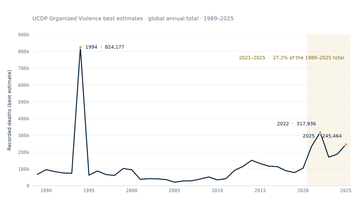

In [4]:
# Figure 1 — one time series, one analytical question.
fig, ax = plt.subplots(figsize=FIGURE_PROFILES["wide"]["figsize"])
fig.subplots_adjust(left=0.09, right=0.975, bottom=0.14, top=0.84)

ax.axvspan(RECENT_START - 0.5, END_YEAR + 0.5, color=COLORS["copper"], alpha=0.11, zorder=0)
ax.plot(
    annual["year"],
    annual["total_deaths"],
    color=COLORS["ink"],
    linewidth=2.4,
    zorder=3,
)

focus_points = annual.loc[annual["year"].isin([peak_year, RECENT_PEAK_YEAR, END_YEAR])].copy()
ax.scatter(
    focus_points["year"],
    focus_points["total_deaths"],
    s=48,
    color=COLORS["copper"],
    edgecolor=COLORS["white"],
    linewidth=1.1,
    zorder=4,
)

annotation_values = {
    peak_year: peak_value,
    RECENT_PEAK_YEAR: recent_peak_value,
    END_YEAR: end_year_value,
}
annotation_offsets = {
    peak_year: (12, -6),
    RECENT_PEAK_YEAR: (-10, 14),
    END_YEAR: (-10, 14),
}
annotation_align = {
    peak_year: "left",
    RECENT_PEAK_YEAR: "right",
    END_YEAR: "right",
}
for year, value in annotation_values.items():
    ax.annotate(
        f"{year}  ·  {fmt_int(value)}",
        xy=(year, value),
        xytext=annotation_offsets[year],
        textcoords="offset points",
        ha=annotation_align[year],
        va="bottom",
        color=COLORS["ink"],
        fontsize=11.5,
        fontfamily=SANS_USED,
        fontweight="medium",
    )

recent_note = f"{RECENT_START}–{END_YEAR}  ·  {fmt_pct(recent_share)} of the {START_YEAR}–{END_YEAR} total"
ax.text(
    END_YEAR - 0.2,
    760_000,
    recent_note,
    ha="right",
    va="center",
    color=COLORS["caution_ink"],
    fontsize=11.5,
    fontfamily=SANS_USED,
    fontweight="medium",
)

ax.set_xlim(START_YEAR - 0.6, END_YEAR + 0.6)
ax.set_ylim(0, 900_000)
xticks = list(range(1990, 2026, 5))
if END_YEAR not in xticks:
    xticks.append(END_YEAR)
ax.set_xticks(sorted(set(xticks)))
ax.set_ylabel("Recorded deaths (best estimate)", labelpad=14)
ax.yaxis.set_major_formatter(FuncFormatter(lambda x, _: "0" if x == 0 else f"{int(x / 1000):,}k"))
style_axis(ax, grid="y")

fig.text(
    0.09,
    0.925,
    f"UCDP Organized Violence best estimates · global annual total · {START_YEAR}–{END_YEAR}",
    ha="left",
    va="top",
    fontsize=13,
    color=COLORS["muted"],
    fontfamily=SANS_USED,
)

fig01_title = "Recent recorded deaths are elevated, but the path is not monotonic"
fig01_caption = (
    f"Annual UCDP organized-violence deaths, best estimates, {START_YEAR}–{END_YEAR}. "
    f"The {RECENT_START}–{END_YEAR} sequence accounts for {fmt_pct(recent_share)} of the period total, "
    "but annual values rise, fall and rise again rather than forming a smooth global trend."
)
fig01_alt = (
    f"Line chart of annual UCDP organized-violence deaths from {START_YEAR} to {END_YEAR}. "
    f"The largest peak is {peak_year} at {fmt_int(peak_value)} deaths. "
    f"The recent sequence is elevated, with {fmt_int(recent_peak_value)} in {RECENT_PEAK_YEAR} and {fmt_int(end_year_value)} in {END_YEAR}, "
    "but it is uneven rather than steadily rising."
)

fig01_paths = export_publication_figure(
    fig,
    "fig01_annual_ucdp_ov_total_deaths_1989_2025.png",
    annual[["year", "total_deaths"]],
    figure_id="fig01",
    title=fig01_title,
    caption=fig01_caption,
    alt_text=fig01_alt,
    measure="Annual UCDP Organized Violence total deaths, best estimate",
    universe="Validated ConflictLens analysis-conflict universe; existing analysis units; global annual sum",
    period=f"{START_YEAR}-{END_YEAR}",
    filters=["analysis_conflict_universe == True", "unit_exists_in_year == True"],
    categorical_mapping={"Annual total": {"color": COLORS["ink"], "treatment": "solid line"}, "Recent window": {"color": COLORS["copper"], "treatment": "light focus band"}},
    notes="The full 1994 peak is preserved. Copper marks the analytical focus window and three focal points only.",
)
plt.show()
display(Image.open(fig01_paths["preview"]))

**Interpretation**  
The recent endpoint is unusually elevated within the record, and 2021–2025 is the highest overlapping five-year window in the best-estimate series. Its margin over 1990–1994 is only 2,358 deaths, however, so the result supports “exceptional” rather than “without precedent.” The path is neither smooth nor monotonic; “has risen again” refers specifically to the climb since 2023.

**Limit**  
A global sum cannot show how evenly deaths or changes are distributed across analytical units. The next section measures the concentration of annual levels and then tests diffusion separately.


<a id="recent-concentration"></a>

## 5. Recent top-two country-year concentration

**Question**  
How much of each annual total from 2021 to 2025 is carried by the two largest positive country-year contributors?

**Method**  
Within each year, retain positive country-year totals, order them descending, select the first two `analysis_unit_label` values and divide their combined total by the validated annual sum. This measures concentration of annual **levels**, not contributions to year-on-year change.

In [5]:
top_two_rows = []
for year in range(RECENT_START, END_YEAR + 1):
    yearly_positive = (
        analysis_conflict.loc[
            analysis_conflict["year"].eq(year)
            & analysis_conflict[TOTAL_METRIC].gt(0),
            ["analysis_unit_id", "analysis_unit_label", TOTAL_METRIC],
        ]
        .sort_values([TOTAL_METRIC, "analysis_unit_label"], ascending=[False, True])
        .reset_index(drop=True)
    )
    assert len(yearly_positive) >= 2
    leaders = yearly_positive.head(2)
    annual_total = int(round(annual.loc[annual["year"].eq(year), "total_deaths"].iloc[0]))
    top_two_total = int(round(leaders[TOTAL_METRIC].sum()))
    combined_share = top_two_total / annual_total
    top_two_rows.append({
        "Year": year,
        "Total deaths": annual_total,
        "Leading country-year contributors": " + ".join(leaders["analysis_unit_label"].tolist()),
        "Combined share": combined_share,
        "Top-two deaths": top_two_total,
        "First contributor": leaders.iloc[0]["analysis_unit_label"],
        "First deaths": int(round(leaders.iloc[0][TOTAL_METRIC])),
        "Second contributor": leaders.iloc[1]["analysis_unit_label"],
        "Second deaths": int(round(leaders.iloc[1][TOTAL_METRIC])),
    })

top_two_detail = pd.DataFrame(top_two_rows)
EXPECTED_TOP_TWO = {
    2021: (235_007, "Ethiopia + Afghanistan", 0.706),
    2022: (317_936, "Ethiopia + Ukraine", 0.835),
    2023: (170_432, "Ukraine + Israel", 0.610),
    2024: (188_209, "Ukraine + Israel", 0.603),
    2025: (245_464, "Ukraine + Sudan", 0.674),
}
for _, row in top_two_detail.iterrows():
    expected_total, expected_labels, expected_share = EXPECTED_TOP_TWO[int(row["Year"])]
    assert int(row["Total deaths"]) == expected_total
    assert row["Leading country-year contributors"] == expected_labels
    assert round(float(row["Combined share"]), 3) == expected_share

article_table = top_two_detail[[
    "Year",
    "Total deaths",
    "Leading country-year contributors",
    "Combined share",
]].copy()
article_table["Total deaths"] = article_table["Total deaths"].map(lambda x: f"{int(x):,}")
article_table["Combined share"] = article_table["Combined share"].map(lambda x: f"{x * 100:.1f}%")

TABLE_CSV_PATH = FIGURE_DIR / "table01_recent_country_year_contributors.csv"
TABLE_MD_PATH = FIGURE_DIR / "table01_recent_country_year_contributors.md"
article_table.to_csv(TABLE_CSV_PATH, index=False)

header = "| " + " | ".join(article_table.columns) + " |"
alignment = "|---:|---:|---|---:|"
rows = [
    "| " + " | ".join(map(str, row)) + " |"
    for row in article_table.itertuples(index=False, name=None)
]
article_table_markdown = "\n".join([header, alignment, *rows]) + "\n"
TABLE_MD_PATH.write_text(article_table_markdown, encoding="utf-8")

expected_markdown = """| Year | Total deaths | Leading country-year contributors | Combined share |
|---:|---:|---|---:|
| 2021 | 235,007 | Ethiopia + Afghanistan | 70.6% |
| 2022 | 317,936 | Ethiopia + Ukraine | 83.5% |
| 2023 | 170,432 | Ukraine + Israel | 61.0% |
| 2024 | 188,209 | Ukraine + Israel | 60.3% |
| 2025 | 245,464 | Ukraine + Sudan | 67.4% |
"""
assert article_table_markdown == expected_markdown
assert pd.read_csv(TABLE_CSV_PATH).astype(str).shape == article_table.astype(str).shape

display(Markdown(article_table_markdown))
display_note(
    "Result",
    "Across all five recent years, the two largest positive country-year contributors account for "
    f"between <strong>{article_table['Combined share'].iloc[3]}</strong> and <strong>{article_table['Combined share'].iloc[1]}</strong> "
    "of the global annual total. The combination changes; the concentration persists.",
    kind="success",
)

| Year | Total deaths | Leading country-year contributors | Combined share |
|---:|---:|---|---:|
| 2021 | 235,007 | Ethiopia + Afghanistan | 70.6% |
| 2022 | 317,936 | Ethiopia + Ukraine | 83.5% |
| 2023 | 170,432 | Ukraine + Israel | 61.0% |
| 2024 | 188,209 | Ukraine + Israel | 60.3% |
| 2025 | 245,464 | Ukraine + Sudan | 67.4% |


**Interpretation**  
The elevated global totals are not distributed evenly across the panel. A small number of country-year observations carry most of each recent annual sum. The degree varies from 60.3% to 83.5%; top-two dominance persists, but concentration is not constant.

**Limit**  
The labels identify analytical units used in the panel arithmetic. They do not identify perpetrators, victims, nationality, targeting, legal responsibility or historical classification. The table measures annual levels only; the next diagnostic asks whether the 2024–2025 rise is geographically diffuse.


### 5.1 Is the 2024–2025 rise geographically diffuse?

**Question**  
Among analytical units with comparable UCDP values in both years, how many rise, fall or remain unchanged?

**Method**  
Pivot the validated best-estimate total for 2024 and 2025, retain only units with non-missing values in both years, and classify the signed difference. Missing observations remain missing and are reported separately.


In [6]:
diffusion_source = analysis_conflict.loc[
    analysis_conflict["year"].isin([COMPARISON_YEAR, END_YEAR]),
    ["analysis_unit_id", "analysis_unit_label", "year", TOTAL_METRIC],
].copy()
diffusion_wide = diffusion_source.pivot(
    index=["analysis_unit_id", "analysis_unit_label"],
    columns="year",
    values=TOTAL_METRIC,
)
missing_by_year = diffusion_wide[[COMPARISON_YEAR, END_YEAR]].isna().sum().astype(int)
diffusion_comparable = diffusion_wide.dropna(subset=[COMPARISON_YEAR, END_YEAR]).copy()
diffusion_comparable["change"] = diffusion_comparable[END_YEAR] - diffusion_comparable[COMPARISON_YEAR]

diffusion_n = int(len(diffusion_comparable))
diffusion_increase_n = int(diffusion_comparable["change"].gt(0).sum())
diffusion_decrease_n = int(diffusion_comparable["change"].lt(0).sum())
diffusion_unchanged_n = int(diffusion_comparable["change"].eq(0).sum())
missing_comparison_n = int(missing_by_year.loc[COMPARISON_YEAR])
missing_end_n = int(missing_by_year.loc[END_YEAR])

assert diffusion_n == 196
assert diffusion_increase_n == 32
assert diffusion_decrease_n == 33
assert diffusion_unchanged_n == 131
assert missing_comparison_n == 53
assert missing_end_n == 53
assert diffusion_increase_n + diffusion_decrease_n + diffusion_unchanged_n == diffusion_n

diffusion_summary = pd.DataFrame([
    {"status": "Increase", "analytical units": diffusion_increase_n},
    {"status": "Decrease", "analytical units": diffusion_decrease_n},
    {"status": "Unchanged", "analytical units": diffusion_unchanged_n},
    {"status": f"Missing in {COMPARISON_YEAR}", "analytical units": missing_comparison_n},
    {"status": f"Missing in {END_YEAR}", "analytical units": missing_end_n},
])
display(diffusion_summary)
display_note(
    "Result",
    f"Among <strong>{diffusion_n}</strong> comparable analytical units, the best-estimate toll rises in "
    f"<strong>{diffusion_increase_n}</strong>, falls in <strong>{diffusion_decrease_n}</strong> and remains unchanged in "
    f"<strong>{diffusion_unchanged_n}</strong>. The worldwide total rises, but most units do not rise with it.",
    kind="success",
)


,status,analytical units
0,Increase,32
1,Decrease,33
2,Unchanged,131
3,Missing in 2024,53
4,Missing in 2025,53


**Interpretation**  
The 2024–2025 increase is not a uniform global movement. Only 32 of 196 comparable units rise in the best-estimate series, while 164 either fall or remain unchanged.

**Limit**  
An unchanged recorded zero is not proof that no lethal violence occurred. UCDP's inclusion rules can preserve a zero even when fatal violence exists below the relevant dyad threshold. The 53 missing units are never converted to zero.


<a id="composition"></a>

## 6. Violence-type composition

**Question**  
Did the recorded composition of organized violence change between 2024 and 2025?

**Method**  
Apply the inherited guarded zero-fill eligibility to the staging components, aggregate state-based, non-state and one-sided deaths by year, and cross-check their sum against the analysis-ready annual total.

**Documented categorical mapping**

- State-based: `ink`, solid fill — dominant structural component.
- Non-state: muted teal, diagonal hatch — secondary category.
- One-sided: `copper`, dotted hatch — the focal category for the 2025 compositional change.

The hatches make the three categories distinguishable without relying on color alone.

In [7]:
RAW_ESTIMATE_COLUMNS = [
    f"{component}_total_deaths_{estimate}"
    for component in ["sb", "ns", "os"]
    for estimate in ["low", "best", "high"]
] + [
    f"cumulative_total_deaths_in_orgvio_{estimate}"
    for estimate in ["low", "best", "high"]
]
for raw_col in RAW_ESTIMATE_COLUMNS:
    ucdp_raw[raw_col] = pd.to_numeric(ucdp_raw[raw_col], errors="raise")

raw_annual = (
    ucdp_raw.loc[ucdp_raw["year"].between(START_YEAR, END_YEAR)]
    .groupby("year", as_index=False)[RAW_ESTIMATE_COLUMNS]
    .sum()
    .sort_values("year")
    .reset_index(drop=True)
)
raw_best_reconciliation = raw_annual[["year", "cumulative_total_deaths_in_orgvio_best"]].merge(
    annual,
    on="year",
    how="left",
    validate="one_to_one",
)
raw_best_reconciliation["difference"] = (
    raw_best_reconciliation["cumulative_total_deaths_in_orgvio_best"]
    - raw_best_reconciliation["total_deaths"]
)
assert raw_best_reconciliation["difference"].eq(0).all()

component_guarded_cols = {
    label: f"{raw_col}_guarded"
    for label, raw_col in RAW_COMPONENTS.items()
}
component_annual = (
    staging_conflict.groupby("year", as_index=False)[list(component_guarded_cols.values())]
    .sum(min_count=1)
    .rename(columns={guarded: label for label, guarded in component_guarded_cols.items()})
    .sort_values("year")
    .reset_index(drop=True)
)
component_annual["Component total"] = component_annual[list(RAW_COMPONENTS)].sum(axis=1, min_count=3)
component_annual = component_annual.merge(annual, on="year", how="left", validate="one_to_one")
component_annual["difference_vs_analysis_ready"] = component_annual["Component total"] - component_annual["total_deaths"]
assert component_annual["difference_vs_analysis_ready"].eq(0).all()

composition = component_annual.loc[
    component_annual["year"].between(COMPOSITION_START, END_YEAR),
    ["year", "State-based", "Non-state", "One-sided", "Component total"],
].copy().reset_index(drop=True)

EXPECTED_COMPONENTS = {
    2021: (200_226, 22_331, 12_450),
    2022: (285_324, 20_093, 12_519),
    2023: (139_149, 19_578, 11_705),
    2024: (155_255, 18_234, 14_720),
    2025: (153_782, 14_936, 76_746),
}
for year, expected in EXPECTED_COMPONENTS.items():
    row = composition.loc[composition["year"].eq(year)].iloc[0]
    observed = tuple(int(round(row[col])) for col in ["State-based", "Non-state", "One-sided"])
    assert observed == expected

row_recent_peak = composition.loc[composition["year"].eq(RECENT_PEAK_YEAR)].iloc[0]
row_comparison = composition.loc[composition["year"].eq(COMPARISON_YEAR)].iloc[0]
row_end = composition.loc[composition["year"].eq(END_YEAR)].iloc[0]
state_share_recent_peak = float(row_recent_peak["State-based"] / row_recent_peak["Component total"])
state_share_end = float(row_end["State-based"] / row_end["Component total"])
onesided_comparison_value = int(round(row_comparison["One-sided"]))
onesided_end_value = int(round(row_end["One-sided"]))
total_change = int(round(row_end["Component total"] - row_comparison["Component total"]))
state_change = int(round(row_end["State-based"] - row_comparison["State-based"]))
nonstate_change = int(round(row_end["Non-state"] - row_comparison["Non-state"]))
onesided_change = int(round(row_end["One-sided"] - row_comparison["One-sided"]))

assert round(state_share_recent_peak * 100, 1) == 89.7
assert round(state_share_end * 100, 1) == 62.6
assert onesided_comparison_value == 14_720
assert onesided_end_value == 76_746

assert total_change == 57_255
assert state_change == -1_473
assert nonstate_change == -3_298
assert onesided_change == 62_026
assert state_change + nonstate_change + onesided_change == total_change
assert onesided_change > total_change and state_change < 0 and nonstate_change < 0


OS_GUARDED = component_guarded_cols["One-sided"]
sudan_os = staging_conflict.loc[
    staging_conflict["analysis_unit_label"].eq("Sudan")
    & staging_conflict["year"].isin([COMPARISON_YEAR, END_YEAR]),
    ["year", OS_GUARDED],
].set_index("year")[OS_GUARDED]
sudan_os_comparison = int(round(sudan_os.loc[COMPARISON_YEAR]))
sudan_os_end = int(round(sudan_os.loc[END_YEAR]))
sudan_os_change = sudan_os_end - sudan_os_comparison
sudan_os_share_end = sudan_os_end / onesided_end_value
sudan_os_change_share = sudan_os_change / onesided_change

assert sudan_os_comparison == 2_316
assert sudan_os_end == 62_775
assert round(sudan_os_share_end * 100, 1) == 81.8
assert sudan_os_change == 60_459
assert round(sudan_os_change_share * 100, 1) == 97.5

raw_by_year = raw_annual.set_index("year")
estimate_sensitivity_rows = []
for estimate in ["low", "best", "high"]:
    state_col = f"sb_total_deaths_{estimate}"
    nonstate_col = f"ns_total_deaths_{estimate}"
    onesided_col = f"os_total_deaths_{estimate}"
    total_col = f"cumulative_total_deaths_in_orgvio_{estimate}"
    estimate_sensitivity_rows.append({
        "estimate": estimate,
        "state-based change": int(raw_by_year.loc[END_YEAR, state_col] - raw_by_year.loc[COMPARISON_YEAR, state_col]),
        "non-state change": int(raw_by_year.loc[END_YEAR, nonstate_col] - raw_by_year.loc[COMPARISON_YEAR, nonstate_col]),
        "one-sided change": int(raw_by_year.loc[END_YEAR, onesided_col] - raw_by_year.loc[COMPARISON_YEAR, onesided_col]),
        "total change": int(raw_by_year.loc[END_YEAR, total_col] - raw_by_year.loc[COMPARISON_YEAR, total_col]),
    })
estimate_sensitivity = pd.DataFrame(estimate_sensitivity_rows).set_index("estimate")
onesided_2024_high = int(raw_by_year.loc[COMPARISON_YEAR, "os_total_deaths_high"])
onesided_2025_low = int(raw_by_year.loc[END_YEAR, "os_total_deaths_low"])
onesided_cross_bound_change = onesided_2025_low - onesided_2024_high
state_variant_changes = estimate_sensitivity["state-based change"].to_dict()

assert onesided_2024_high == 17_422
assert onesided_2025_low == 20_221
assert onesided_cross_bound_change == 2_799
assert estimate_sensitivity.loc["low", "one-sided change"] == 8_345
assert estimate_sensitivity.loc["best", "one-sided change"] == 62_026
assert estimate_sensitivity.loc["high", "one-sided change"] == 78_306
assert state_variant_changes == {"low": 9_737, "best": -1_473, "high": 41_324}

comparison_label = str(COMPARISON_YEAR)
end_label = str(END_YEAR)
change_summary = pd.DataFrame([
    {"component": "Total", comparison_label: int(row_comparison["Component total"]), end_label: int(row_end["Component total"]), "change": total_change},
    {"component": "State-based", comparison_label: int(row_comparison["State-based"]), end_label: int(row_end["State-based"]), "change": state_change},
    {"component": "Non-state", comparison_label: int(row_comparison["Non-state"]), end_label: int(row_end["Non-state"]), "change": nonstate_change},
    {"component": "One-sided", comparison_label: int(row_comparison["One-sided"]), end_label: int(row_end["One-sided"]), "change": onesided_change},
])
display(change_summary)
display(estimate_sensitivity)

descriptive_conclusion = (
    f"The net increase from {COMPARISON_YEAR} to {END_YEAR} is entirely driven by the increase in one-sided violence; "
    "state-based and non-state deaths both decline slightly."
)
display_note("Validated descriptive conclusion", descriptive_conclusion, kind="success")
display_note(
    "Sensitivity boundary",
    f"Sudan contributes <strong>{fmt_pct(sudan_os_share_end)}</strong> of the {END_YEAR} one-sided best estimate and "
    f"<strong>{fmt_pct(sudan_os_change_share)}</strong> of its worldwide increase since {COMPARISON_YEAR}. "
    f"The one-sided increase remains positive even under the cross-bound comparison "
    f"({fmt_int(onesided_2025_low)} low in {END_YEAR} vs {fmt_int(onesided_2024_high)} high in {COMPARISON_YEAR}). "
    "The small state-based decline does not persist across low/high estimate variants.",
    kind="warning",
)

,component,2024,2025,change
0,Total,188209,245464,57255
1,State-based,155255,153782,-1473
2,Non-state,18234,14936,-3298
3,One-sided,14720,76746,62026


,state-based change,non-state change,one-sided change,total change
estimate,,,,
low,9737,-210,8345,17872
best,-1473,-3298,62026,57255
high,41324,-200,78306,119430


findfont: Failed to find font weight medium, now using 400.


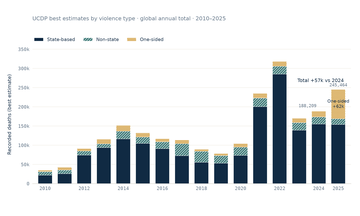

In [8]:
# Figure 2 — real composition shown with stable category order and a zero baseline.
fig, ax = plt.subplots(figsize=FIGURE_PROFILES["wide"]["figsize"])
fig.subplots_adjust(left=0.09, right=0.975, bottom=0.15, top=0.79)

x = np.arange(len(composition))
bar_width = 0.72
category_styles = {
    "State-based": {"color": COLORS["ink"], "hatch": ""},
    "Non-state": {"color": CATEGORICAL[2], "hatch": "////"},
    "One-sided": {"color": COLORS["copper"], "hatch": "...."},
}
bottom = np.zeros(len(composition))
for category in ["State-based", "Non-state", "One-sided"]:
    values = composition[category].to_numpy()
    style = category_styles[category]
    ax.bar(
        x,
        values,
        width=bar_width,
        bottom=bottom,
        label=category,
        color=style["color"],
        hatch=style["hatch"],
        edgecolor=COLORS["white"],
        linewidth=0.65,
        zorder=3,
    )
    bottom += values

idx_comparison = int(composition.index[composition["year"].eq(COMPARISON_YEAR)][0])
idx_end = int(composition.index[composition["year"].eq(END_YEAR)][0])
total_comparison = int(round(row_comparison["Component total"]))
total_end = int(round(row_end["Component total"]))
onesided_end = int(round(row_end["One-sided"]))
onesided_base_end = int(round(row_end["State-based"] + row_end["Non-state"]))

ax.text(
    idx_end + 0.28,
    total_end + 16_000,
    f"Total {fmt_delta_k(total_change)} vs {COMPARISON_YEAR}",
    ha="right",
    va="bottom",
    color=COLORS["ink"],
    fontsize=11.5,
    fontfamily=SANS_USED,
    fontweight="medium",
)
ax.text(
    idx_end,
    onesided_base_end + onesided_end / 2,
    f"One-sided\n{fmt_delta_k(onesided_change)}",
    ha="center",
    va="center",
    color=COLORS["navy_2"],
    fontsize=10.5,
    fontfamily=SANS_USED,
    fontweight="medium",
)
ax.text(
    idx_comparison - 0.12,
    total_comparison + 8_000,
    fmt_int(total_comparison),
    ha="right",
    va="bottom",
    color=COLORS["muted"],
    fontsize=10.5,
    fontfamily=MONO_USED,
)
ax.text(
    idx_end,
    total_end + 5_000,
    fmt_int(total_end),
    ha="center",
    va="bottom",
    color=COLORS["muted"],
    fontsize=10.5,
    fontfamily=MONO_USED,
)

selected_years = [year for year in range(COMPOSITION_START, END_YEAR + 1) if (year - COMPOSITION_START) % 2 == 0]
if END_YEAR not in selected_years:
    selected_years.append(END_YEAR)
selected_positions = [int(composition.index[composition["year"].eq(year)][0]) for year in selected_years]
ax.set_xticks(selected_positions, [str(year) for year in selected_years])
ax.set_xlim(-0.65, len(composition) - 0.35)
ax.set_ylim(0, 360_000)
ax.set_ylabel("Recorded deaths (best estimate)", labelpad=14)
ax.yaxis.set_major_formatter(FuncFormatter(lambda value, _: "0" if value == 0 else f"{int(value / 1000):,}k"))
style_axis(ax, grid="y")

legend = ax.legend(
    loc="lower left",
    bbox_to_anchor=(0.0, 1.01),
    ncol=3,
    frameon=False,
    handlelength=2.0,
    columnspacing=1.8,
    borderaxespad=0,
)
for text in legend.get_texts():
    text.set_color(COLORS["navy_2"])
    text.set_fontfamily(SANS_USED)

fig.text(
    0.09,
    0.925,
    f"UCDP best estimates by violence type · global annual total · {COMPOSITION_START}–{END_YEAR}",
    ha="left",
    va="top",
    fontsize=13,
    color=COLORS["muted"],
    fontfamily=SANS_USED,
)

fig02_title = f"The {END_YEAR} increase has a different recorded composition"
fig02_caption = (
    f"Annual UCDP organized-violence deaths by category, best estimates, {COMPOSITION_START}–{END_YEAR}. "
    f"Between {COMPARISON_YEAR} and {END_YEAR}, the total rises by {fmt_int(total_change)}, while one-sided deaths rise by {fmt_int(onesided_change)}; "
    "state-based and non-state deaths both decline slightly."
)
fig02_alt = (
    f"Stacked annual bars for state-based, non-state and one-sided violence from {COMPOSITION_START} to {END_YEAR}. "
    f"The {RECENT_PEAK_YEAR} peak is mostly state-based. In {END_YEAR}, the total increases by about {fmt_int(total_change)} from {COMPARISON_YEAR}, "
    f"while the one-sided component increases by about {fmt_int(onesided_change)} and becomes much larger than in prior years."
)

fig02_paths = export_publication_figure(
    fig,
    "fig02_annual_ucdp_ov_deaths_by_type_2010_2025.png",
    composition[["year", "State-based", "Non-state", "One-sided", "Component total"]],
    figure_id="fig02",
    title=fig02_title,
    caption=fig02_caption,
    alt_text=fig02_alt,
    measure="Annual UCDP Organized Violence deaths by state-based, non-state and one-sided category, best estimates",
    universe="Validated ConflictLens analysis-conflict universe; existing analysis units; global annual sums",
    period=f"{COMPOSITION_START}-{END_YEAR}",
    filters=["analysis_conflict_universe == True", "unit_exists_in_year == True", "guarded zero-fill only where ucdp_ov_can_zero_fill == True"],
    categorical_mapping={
        "State-based": {"color": COLORS["ink"], "treatment": "solid fill"},
        "Non-state": {"color": CATEGORICAL[2], "treatment": "diagonal hatch"},
        "One-sided": {"color": COLORS["copper"], "treatment": "dotted hatch; focal category"},
    },
    notes="Stacked bars encode a real composition. Stable order and hatches preserve interpretation in grayscale.",
)
plt.show()
display(Image.open(fig02_paths["preview"]))

**Interpretation**  
The later increase is not built from the same recorded category mix as the 2022 peak. In the best-estimate series, the 2024–2025 net increase is accounted for by one-sided violence; state-based and non-state deaths decline slightly. State-based violence nevertheless remains the majority of the 2025 total at 62.6%.

The one-sided change is itself highly concentrated: Sudan contributes 81.8% of the 2025 one-sided best estimate and about 97.5% of its worldwide increase since 2024. This is a statistical country-year contribution, not an attribution of responsibility.

**Sensitivity**  
The one-sided increase remains positive across UCDP's low, best and high variants, including the conservative cross-bound comparison of the 2025 low estimate with the 2024 high estimate. The small state-based decline does not persist across estimate variants and must therefore be described as a best-estimate result.

**Limit**  
“Accounted for” refers only to additive arithmetic across the recorded categories. Low and high estimates are uncertainty variants, not formal confidence intervals. None of these calculations explains the underlying conflicts.


<a id="outputs"></a>

## 7. Article-ready outputs

The notebook exports:

- two opaque white-background PNG figures;
- two matching SVG files;
- the exact data table plotted by each figure;
- one metadata JSON per figure, including caption, source, alt text, categorical mapping, font fallback and source-commit status;
- one recent-contributor table in CSV and article-ready Markdown;
- 360 px validation previews used only for inspection.

No figure number, outer Ghost frame, source strip, ConflictLens wordmark or long methodology block is embedded in the analytical image.

In [9]:
figure_manifest = pd.DataFrame([
    {
        "figure": "fig01",
        "png": str(fig01_paths["png"].relative_to(PROJECT_ROOT)),
        "svg": str(fig01_paths["svg"].relative_to(PROJECT_ROOT)),
        "data": str(fig01_paths["data"].relative_to(PROJECT_ROOT)),
        "metadata": str(fig01_paths["metadata"].relative_to(PROJECT_ROOT)),
        "mobile preview": str(fig01_paths["preview"].relative_to(PROJECT_ROOT)),
    },
    {
        "figure": "fig02",
        "png": str(fig02_paths["png"].relative_to(PROJECT_ROOT)),
        "svg": str(fig02_paths["svg"].relative_to(PROJECT_ROOT)),
        "data": str(fig02_paths["data"].relative_to(PROJECT_ROOT)),
        "metadata": str(fig02_paths["metadata"].relative_to(PROJECT_ROOT)),
        "mobile preview": str(fig02_paths["preview"].relative_to(PROJECT_ROOT)),
    },
])
table_manifest = pd.DataFrame([
    {"format": "CSV", "path": str(TABLE_CSV_PATH.relative_to(PROJECT_ROOT))},
    {"format": "Markdown", "path": str(TABLE_MD_PATH.relative_to(PROJECT_ROOT))},
])
display(figure_manifest)
display(table_manifest)

,figure,png,svg,data,metadata,mobile preview
0,fig01,figures\the-line-is-rising-but-not-everywhere\fig01_annual_ucdp_ov_total_deaths_1989_2025.png,figures\the-line-is-rising-but-not-everywhere\fig01_annual_ucdp_ov_total_deaths_1989_2025.svg,figures\the-line-is-rising-but-not-everywhere\fig01_annual_ucdp_ov_total_deaths_1989_2025_data.csv,figures\the-line-is-rising-but-not-everywhere\fig01_annual_ucdp_ov_total_deaths_1989_2025_metadata.json,figures\the-line-is-rising-but-not-everywhere\validation\fig01_annual_ucdp_ov_total_deaths_1989_2025_360px.png
1,fig02,figures\the-line-is-rising-but-not-everywhere\fig02_annual_ucdp_ov_deaths_by_type_2010_2025.png,figures\the-line-is-rising-but-not-everywhere\fig02_annual_ucdp_ov_deaths_by_type_2010_2025.svg,figures\the-line-is-rising-but-not-everywhere\fig02_annual_ucdp_ov_deaths_by_type_2010_2025_data.csv,figures\the-line-is-rising-but-not-everywhere\fig02_annual_ucdp_ov_deaths_by_type_2010_2025_metadata.json,figures\the-line-is-rising-but-not-everywhere\validation\fig02_annual_ucdp_ov_deaths_by_type_2010_2025_360px.png


,format,path
0,CSV,figures\the-line-is-rising-but-not-everywhere\table01_recent_country_year_contributors.csv
1,Markdown,figures\the-line-is-rising-but-not-everywhere\table01_recent_country_year_contributors.md


<a id="validation"></a>

## 8. Assertions and validation summary

The final gate checks the analytical targets, component reconciliation, table fidelity, export formats, dimensions, backgrounds, SVG presence, mobile previews, font detection and the absence of Ghost-layer strings in the SVG files.

In [10]:
validation_rows: list[dict[str, object]] = []


def add_check(check: str, passed: bool, detail: str) -> None:
    validation_rows.append({"check": check, "passed": bool(passed), "detail": detail})


add_check("analysis-ready exact shape", analysis_ready.shape == (9_287, 66), f"observed={analysis_ready.shape}")
add_check("analysis-ready year range", (analysis_ready.year.min(), analysis_ready.year.max()) == (START_YEAR, END_YEAR), f"observed={analysis_ready.year.min()}–{analysis_ready.year.max()}")
add_check("analysis-ready unique key", not analysis_ready.duplicated(["analysis_unit_id", "year"]).any(), f"duplicates={analysis_ready.duplicated(['analysis_unit_id', 'year']).sum()}")
add_check("staging unique key", not staging.duplicated(["analysis_unit_id", "year"]).any(), f"duplicates={staging.duplicated(['analysis_unit_id', 'year']).sum()}")
add_check("UCDP raw exact shape", ucdp_raw.shape == (7_132, 74), f"observed={ucdp_raw.shape}")
add_check("UCDP raw version", set(ucdp_raw["Version"].dropna().astype(str)) == {"26.1"}, f"observed={sorted(ucdp_raw['Version'].dropna().astype(str).unique())}")
add_check("full-period total", period_total == 4_257_891, f"observed={period_total:,}")
add_check("recent-period total", recent_total == 1_157_048, f"observed={recent_total:,}")
add_check("recent-period article share", round(recent_share * 100, 1) == 27.2, f"observed={recent_share:.8f}")
add_check("seven years cross half", years_to_half == 7, f"observed={years_to_half}; years={half_years}")
add_check("five recent years in half set", recent_years_in_half == [2021, 2022, 2023, 2024, 2025], f"observed={recent_years_in_half}")
add_check("latest five-year window ranks first", (int(recent_window["window_start"]), int(recent_window["window_end"]), int(recent_window["window_total"])) == (2021, 2025, 1_157_048), f"observed={recent_window.to_dict()}")
add_check("five-year runner-up", (int(runner_up_window["window_start"]), int(runner_up_window["window_end"]), int(runner_up_window["window_total"])) == (1990, 1994, 1_154_690), f"observed={runner_up_window.to_dict()}")
add_check("five-year lead", rolling_gap == 2_358 and round(rolling_gap_share * 100, 1) == 0.2, f"gap={rolling_gap}; share={rolling_gap_share:.8f}")
add_check("recent annual totals", observed_recent_totals == EXPECTED_RECENT_TOTALS, f"observed={observed_recent_totals}")
add_check("recent top-two rows", len(top_two_detail) == 5, f"rows={len(top_two_detail)}")
add_check("2024–2025 comparable units", diffusion_n == 196, f"observed={diffusion_n}")
add_check("2024–2025 diffusion counts", (diffusion_increase_n, diffusion_decrease_n, diffusion_unchanged_n) == (32, 33, 131), f"observed={(diffusion_increase_n, diffusion_decrease_n, diffusion_unchanged_n)}")
add_check("recent missing values preserved", (missing_comparison_n, missing_end_n) == (53, 53), f"observed={(missing_comparison_n, missing_end_n)}")
add_check("Markdown table exact", TABLE_MD_PATH.read_text(encoding="utf-8") == expected_markdown, f"path={TABLE_MD_PATH}")
add_check("component totals reconcile for every year", component_annual["difference_vs_analysis_ready"].eq(0).all(), f"max_abs_difference={component_annual['difference_vs_analysis_ready'].abs().max()}")
add_check("raw best totals reconcile for every year", raw_best_reconciliation["difference"].eq(0).all(), f"max_abs_difference={raw_best_reconciliation['difference'].abs().max()}")
add_check("2022 state-based share", round(state_share_recent_peak * 100, 1) == 89.7, f"observed={state_share_recent_peak:.8f}")
add_check("2025 state-based share", round(state_share_end * 100, 1) == 62.6, f"observed={state_share_end:.8f}")
add_check("2024 one-sided value", onesided_comparison_value == 14_720, f"observed={onesided_comparison_value:,}")
add_check("2025 one-sided value", onesided_end_value == 76_746, f"observed={onesided_end_value:,}")
add_check("2024→2025 total change", total_change == 57_255, f"observed={total_change:,}")
add_check("2024→2025 state-based change", state_change == -1_473, f"observed={state_change:,}")
add_check("2024→2025 non-state change", nonstate_change == -3_298, f"observed={nonstate_change:,}")
add_check("2024→2025 one-sided change", onesided_change == 62_026, f"observed={onesided_change:,}")
add_check("net increase arithmetic", state_change + nonstate_change + onesided_change == total_change, f"sum={state_change + nonstate_change + onesided_change:,}")
add_check("Sudan 2025 one-sided value", sudan_os_end == 62_775, f"observed={sudan_os_end:,}")
add_check("Sudan 2025 one-sided share", round(sudan_os_share_end * 100, 1) == 81.8, f"observed={sudan_os_share_end:.8f}")
add_check("Sudan share of one-sided increase", sudan_os_change == 60_459 and round(sudan_os_change_share * 100, 1) == 97.5, f"change={sudan_os_change:,}; share={sudan_os_change_share:.8f}")
add_check("one-sided increase survives cross-bound check", onesided_cross_bound_change == 2_799 and onesided_cross_bound_change > 0, f"observed={onesided_cross_bound_change:,}")
add_check("one-sided variant changes", estimate_sensitivity["one-sided change"].to_dict() == {"low": 8_345, "best": 62_026, "high": 78_306}, f"observed={estimate_sensitivity['one-sided change'].to_dict()}")
add_check("state-based decline is best-estimate-only", state_variant_changes == {"low": 9_737, "best": -1_473, "high": 41_324}, f"observed={state_variant_changes}")

for figure_id, paths in [("fig01", fig01_paths), ("fig02", fig02_paths)]:
    for kind in ["png", "svg", "data", "metadata", "preview"]:
        path = paths[kind]
        add_check(f"{figure_id} {kind} exists", path.exists() and path.stat().st_size > 0, f"bytes={path.stat().st_size if path.exists() else 0}")
    with Image.open(paths["png"]) as image:
        add_check(f"{figure_id} canonical dimensions", image.size == (2400, 1440), f"observed={image.size}")
        rgba = image.convert("RGBA")
        alpha_extrema = rgba.getchannel("A").getextrema()
        corners = [
            rgba.getpixel((0, 0)),
            rgba.getpixel((rgba.width - 1, 0)),
            rgba.getpixel((0, rgba.height - 1)),
            rgba.getpixel((rgba.width - 1, rgba.height - 1)),
        ]
        white_and_opaque = alpha_extrema == (255, 255) and all(pixel == (255, 255, 255, 255) for pixel in corners)
        add_check(f"{figure_id} opaque white background", white_and_opaque, f"alpha_extrema={alpha_extrema}; corners={corners}")
    with Image.open(paths["preview"]) as preview:
        add_check(f"{figure_id} 360px preview", preview.width == 360, f"observed={preview.size}")
    svg_text = paths["svg"].read_text(encoding="utf-8")
    prohibited = ["FIG. 0", "SOURCE →", "ConflictLens wordmark", "figure plate"]
    found = [token for token in prohibited if token in svg_text]
    add_check(f"{figure_id} contains no Ghost chrome strings", not found, f"found={found}")

for table_path in [TABLE_CSV_PATH, TABLE_MD_PATH]:
    add_check(f"table export exists — {table_path.suffix}", table_path.exists() and table_path.stat().st_size > 0, f"bytes={table_path.stat().st_size if table_path.exists() else 0}")

add_check("font fallback reported", bool(SANS_USED and MONO_USED), f"sans={SANS_USED}; mono={MONO_USED}; IBM_PLEX_AVAILABLE={IBM_PLEX_AVAILABLE}")
add_check("source commit status reported", bool(SOURCE_COMMIT or SOURCE_COMMIT_STATUS), f"commit={SOURCE_COMMIT}; status={SOURCE_COMMIT_STATUS}")

validation_report = pd.DataFrame(validation_rows)
display(validation_report)
if not validation_report["passed"].all():
    failed = validation_report.loc[~validation_report["passed"]]
    raise AssertionError("Validation failed:\n" + failed.to_string(index=False))

VALIDATION_JSON_PATH = FIGURE_DIR / "validation_summary.json"
validation_payload = {
    "article_slug": ARTICLE_SLUG,
    "notebook": f"notebooks/articles/{NOTEBOOK_NAME}",
    "source_commit": SOURCE_COMMIT,
    "source_commit_status": SOURCE_COMMIT_STATUS,
    "analysis_ready_input": str(ANALYSIS_READY_PATH),
    "staging_input": str(STAGING_PATH),
    "ucdp_raw_sensitivity_input": str(RAW_UCDP_PATH),
    "python": sys.version.split()[0],
    "package_versions": package_versions,
    "font_sans": SANS_USED,
    "font_mono": MONO_USED,
    "ibm_plex_available": IBM_PLEX_AVAILABLE,
    "checks_passed": int(validation_report["passed"].sum()),
    "checks_total": int(len(validation_report)),
    "all_checks_passed": bool(validation_report["passed"].all()),
    "mobile_inspection": {
        "width_css_px": 360,
        "status": "Previews generated for explicit visual inspection; final manual review recorded in the implementation report.",
    },
    "generated_at_utc": datetime.now(timezone.utc).isoformat(),
}
VALIDATION_JSON_PATH.write_text(json.dumps(validation_payload, indent=2, ensure_ascii=False), encoding="utf-8")

display_note(
    "All validation checks passed",
    f"<strong>{len(validation_report)}</strong> analytical, export and publication-contract checks passed. "
    f"Both canonical PNG files are 2400 × 1440 px with opaque backgrounds and matching SVG exports. "
    f"Font configuration: <code>{SANS_USED}</code> / <code>{MONO_USED}</code>.",
    kind="success",
)

,check,passed,detail
0,analysis-ready exact shape,True,"observed=(9287, 66)"
1,analysis-ready year range,True,observed=1989–2025
2,analysis-ready unique key,True,duplicates=0
3,staging unique key,True,duplicates=0
4,UCDP raw exact shape,True,"observed=(7132, 74)"
5,UCDP raw version,True,observed=['26.1']
6,full-period total,True,"observed=4,257,891"
7,recent-period total,True,"observed=1,157,048"
8,recent-period article share,True,observed=0.27174204
9,seven years cross half,True,"observed=7; years=[1994, 2022, 2025, 2021, 2024, 2023, 2014]"


<a id="reproduction"></a>

## 9. Reproduction notes

- Restart the kernel and run all cells from the repository root.
- Place the validated private panels at one of the normal candidate paths listed in the data-loading cell.
- Place the official UCDP Organized Violence v26.1 archive at `data/ucdp/organizedviolencecy-261-csv.zip`; it is used only for low/high fields absent from the panels.
- The notebook does not download data, fonts or external interpretation sources.
- The analysis-ready panel supplies the validated total series, rolling-window comparison, country-year ranking and diffusion diagnostic.
- The staging panel supplies the decomposed best-estimate fields and the Sudan one-sided concentration check.
- The raw UCDP archive supplies low/high sensitivity fields; its globally aggregated best-estimate series reconciles exactly to the analysis-ready annual totals for every year from 1989 to 2025.
- `0` and `NA` remain distinct. A staging `NA` is replaced by zero only when the existing `ucdp_ov_can_zero_fill` rule explicitly permits it; all other missing values remain missing.
- A recorded zero is not proof of no lethal violence: UCDP's inclusion threshold can preserve zeros for fatal activity below the relevant dyad threshold.
- UCDP low and high estimates are treated as sensitivity variants, not formal confidence intervals.
- The supplied archive contains no `.git` directory, so an exact source commit cannot be recovered from this workspace. The notebook records that status rather than inventing a SHA.
- IBM Plex is used only when installed locally. Otherwise the detected DejaVu fallback is reported in figure metadata and the validation summary.
- The notebook export contains the analytical graphic only. Figure numbering, captions, sources, methodology notes, alt text and breakout width belong to the Ghost layer.


In [11]:
execution_summary = pd.DataFrame([
    {"item": "Article period total", "value": f"{period_total:,}"},
    {"item": "Recent period total", "value": f"{recent_total:,}"},
    {"item": "Recent period share", "value": fmt_pct(recent_share)},
    {"item": "Five-year lead vs 1990–1994", "value": f"{rolling_gap:,} ({fmt_pct(rolling_gap_share)})"},
    {"item": "Top-two table rows", "value": len(article_table)},
    {"item": "2024→2025 comparable units", "value": f"{diffusion_n} ({diffusion_increase_n} up / {diffusion_decrease_n} down / {diffusion_unchanged_n} unchanged)"},
    {"item": "2024→2025 total change", "value": f"{total_change:+,}"},
    {"item": "2024→2025 one-sided change", "value": f"{onesided_change:+,}"},
    {"item": "Sudan share of 2025 one-sided", "value": fmt_pct(sudan_os_share_end)},
    {"item": "Sudan share of one-sided increase", "value": fmt_pct(sudan_os_change_share)},
    {"item": "One-sided cross-bound change", "value": f"{onesided_cross_bound_change:+,}"},
    {"item": "Figure exports", "value": "2 PNG + 2 SVG + 2 data CSV + 2 metadata JSON"},
    {"item": "Table exports", "value": "CSV + Markdown"},
    {"item": "Validation", "value": f"{len(validation_report)}/{len(validation_report)} checks passed"},
    {"item": "Fonts", "value": f"{SANS_USED} / {MONO_USED}"},
    {"item": "Source commit", "value": SOURCE_COMMIT or SOURCE_COMMIT_STATUS},
])
display(execution_summary)

,item,value
0,Article period total,"4,257,891"
1,Recent period total,"1,157,048"
2,Recent period share,27.2%
3,Five-year lead vs 1990–1994,"2,358 (0.2%)"
4,Top-two table rows,5
5,2024→2025 comparable units,196 (32 up / 33 down / 131 unchanged)
6,2024→2025 total change,"+57,255"
7,2024→2025 one-sided change,"+62,026"
8,Sudan share of 2025 one-sided,81.8%
9,Sudan share of one-sided increase,97.5%
